<center><font size=6>Word Embeddings - Hands-on</font></center>

# **Problem Statement**

In the fast-evolving landscape of the entertainment industry, it is important to gauge audience sentiments towards movie releases. Understanding the sentiments expressed in movie reviews is crucial for shaping marketing strategies, refining content creation, and ultimately enhancing the overall viewer experience. However, manually analyzing an extensive volume of reviews is time-consuming and may not capture nuanced sentiments at scale. To address this, we aim to develop an ML-based sentiment analyzer that automatically evaluates movie reviews, providing actionable insights into audience perceptions.

# **Data Dictionary**

- **review**: review of a movie
- **sentiment**: indicates the sentiment of the review ( 0 is for negative review and 1 for positive review)

# **Installing and Importing Necessary Libraries**

In [56]:
# Installing the libraries with the specified version
# !pip install unidecode==1.4.0 gensim==4.3.3 zeugma==0.41 fasttext==0.9.3 pandas==2.2.2 numpy==1.26.4 matplotlib==3.10.0 seaborn==0.13.2 nltk==3.9.1 scikit-learn==1.6.1 -q

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [49]:
# !pip install spacy
#!python -m spacy download en_core_web_sm

In [50]:
#!pip install --upgrade gensim numpy
# %pip install pandas matplotlib scikit-learn seaborn numpy nltk spacy

In [51]:
#!pip install --upgrade gensim
#!pip install gensim
#!pip install --upgrade pip setuptools wheel
#!pip install gensim==4.3.3
#!pip install --upgrade gensim
#!pip install matplotlib

In [23]:
# to read and manipulate the data
import pandas as pd
import numpy as np
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# to use regular expressions for manipulating text data
import re

# to manipulate string data
import string

# to remove the accented characters
# import unidecode

# to load the natural language toolkit
import nltk
nltk.download('stopwords')    # loading the stopwords
# nltk.download('punkt')    # loading the punkt module used in tokenization
# nltk.download('omw-1.4')    # dependency for tokenization
nltk.download('wordnet')    # loading the wordnet module that is used in stemming

# to remove common stop words
from nltk.corpus import stopwords

# to visualize text data using wordcloud
# from wordcloud import STOPWORDS

# to perform stemming
from nltk.stem.porter import PorterStemmer

# to perform tokenization
# from nltk.tokenize import word_tokenize, sent_tokenize

#download en_core_web_sm once
#!python -m spacy download en_core_web_sm

#for python version 3.12, you have to force install once
#%pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl


# Importing the SpaCy library
import spacy
nlp = spacy.load('en_core_web_sm') # loading the envrionment config

# Used in tokenization
from spacy.lang.en import English

# To create Bag of Words
from sklearn.feature_extraction.text import CountVectorizer

# To create TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# To import Word2Vec
from gensim.models import Word2Vec

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

[nltk_data] Downloading package stopwords to C:\Users\Jitendra
[nltk_data]     Manwani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Jitendra
[nltk_data]     Manwani\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# **Importing the dataset**

In [13]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# loading data into a pandas dataframe
reviews = pd.read_csv("imdb_10K_sentimnets_reviews.csv")

In [4]:
reviews.shape

(10000, 2)

In [5]:
reviews.head()

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

In [6]:
# creating a copy of the data # only top 1000
data = reviews.loc[0:1000]

##### We work with only the first 1,001 reviews. Why? Word2Vec training and Random Forest on dense vectors are computationally heavy. 

# **Data Overview**

## **Checking the first 5 rows**

In [7]:
data.head(5)

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

* Here, a sentiment value of **0 is negative** and **1 is positive**.

## **Checking the shape of the data**

In [8]:
data.shape

(1001, 2)

* The original dataset has 10000 rows and 2 columns.

## **Checking for missing values**

In [9]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

* There are no missing values in the data

## **Checking for duplicate values**

In [10]:
# checking for duplicate values
dup = data.duplicated().sum()
print(dup)

0


In [11]:
# keeping only the first occurence of duplicate values and dropping the rest
data = data.drop_duplicates(keep = 'first')

In [12]:
# reseting the index of the dataframe
data = data.reset_index(drop = True)

## **Checking the distribution of sentiments**

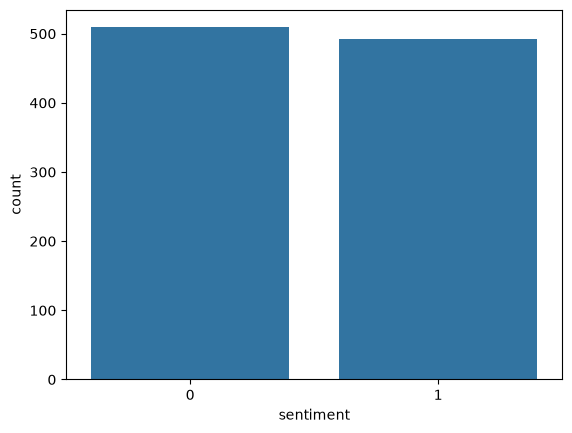

In [13]:
#!pip install seaborn
import seaborn as sns
sns.countplot(data=data, x='sentiment');

- There are almost an equal number of positive and negative reviews.

# **Text Preprocessing**

### **Removing special characters**

In [14]:
# defining a function to remove special characters
def remove_special_characters(text):
    # Defining the regex pattern to match non-alphanumeric characters
    pattern = '[^A-Za-z0-9]+' 

    # Finding the specified pattern and replacing non-alphanumeric characters with a blank string
    new_text = ''.join(re.sub(pattern, ' ', text))

    return new_text

    
-> [^A-Za-z0-9]+ is a regex (regular expression). It means: "find every character that is NOT (^) 
    an uppercase letter, lowercase letter, or digit — and grab them in groups (+).
-> re.sub(pattern, ' ', text) replaces each match with a space.    

In [15]:
# !pip install regex
import re
# Applying the function to remove special characters
data['cleaned_text'] = data['review'].apply(remove_special_characters)

In [16]:
# checking a couple of instances of cleaned data
data.loc[0:3, ['review','cleaned_text']]

,review,cleaned_text
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",Okay I know this does nt project India in a good light But the overall theme of the movie is not India it s Shakti The power of a warlord and the power of a mother The relationship between Nandini and her husband and son swallow you up in their warmth Then things go terribly wrong The interaction between Nandini and her father in law the power of their dysfunctional relationship and the lives changed by it are the strengths of this movie Shah Rukh Khan s performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor It is easy to get caught up in the love violence and redemption of lives in this film and find yourself heaving a sigh of relief and sadness at the climax The musical interludes are strengths believable and well done
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",Despite John Travolta s statements in interviews that this was his favorite role of his career Be Cool proves to be a disappointing sequel to 1995 s witty and clever Get Shorty br br Travolta delivers a pleasant enough performance in this mildly entertaining film but ultimately the movie falls flat due to an underdeveloped plot unlikeable characters and a surprising lack of chemistry between leads Travolta and Uma Thurman Although there are some laughs this unfunny dialog example which appeared frequently in the trailers kind of says it all Thurman Do you dance Travo

- We can observe that regex removed the special characters in the 3rd review, like '!', '<', and retained the alphabets.

### **Lowercasing**

In [17]:
# changing the case of the text data to lower case
data['cleaned_text'] = data['cleaned_text'].str.lower()

In [18]:
# checking a couple of instances of cleaned data
data.loc[0:3, ['review','cleaned_text']]

,review,cleaned_text
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",okay i know this does nt project india in a good light but the overall theme of the movie is not india it s shakti the power of a warlord and the power of a mother the relationship between nandini and her husband and son swallow you up in their warmth then things go terribly wrong the interaction between nandini and her father in law the power of their dysfunctional relationship and the lives changed by it are the strengths of this movie shah rukh khan s performance seems to be a mere cameo compared to the believable desperation of karisma kapoor it is easy to get caught up in the love violence and redemption of lives in this film and find yourself heaving a sigh of relief and sadness at the climax the musical interludes are strengths believable and well done
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",despite john travolta s statements in interviews that this was his favorite role of his career be cool proves to be a disappointing sequel to 1995 s witty and clever get shorty br br travolta delivers a pleasant enough performance in this mildly entertaining film but ultimately the movie falls flat due to an underdeveloped plot unlikeable characters and a surprising lack of chemistry between leads travolta and uma thurman although there are some laughs this unfunny dialog example which appeared frequently in the trailers kind of says it all thurman do you dance travo

- We can observe that all the text has now successfully been converted to lower case.

### **Removing extra whitespace**

In [19]:
# removing extra whitespaces from the text
data['cleaned_text'] = data['cleaned_text'].str.strip()

In [20]:
# checking a couple of instances of cleaned data
data.loc[5:6, ['review','cleaned_text']]

,review,cleaned_text
5,"I just watched Nightbreed for the first time since seeing it in the theater almost 20 years ago, and while I remember liking it at the time, I don't remember being blown away by it like I was today. I really can't complain about anything in this movie. Craig Scheffer is excellent as the lead character of Boone. I never understood why he hasn't had a more successful career, because most of his early work is outstanding. As good as Scheffer is, Cronenberg is even better. His portrayal of the psycho Dr. Decker is unforgettable, and steals the show. The rest of the cast, which includes Doug Bradley is very good, save for the ridiculously over the top redneck sheriff. The visuals are good, and in some shots great. The Danny Elfman composed score is as good as it gets, and is among his best work. The ending was epic, with nonstop action for close to twenty minutes. Overall, Nightbreed is a tremendous accomplishment for Clive Barker, and ranks as my favorite of his movies, just slightly ahead of Hellraiser. 9/10",i just watched nightbreed for the first time since seeing it in the theater almost 20 years ago and while i remember liking it at the time i don t remember being blown away by it like i was today i really can t complain about anything in this movie craig scheffer is excellent as the lead character of boone i never understood why he hasn t had a more successful career because most of his early work is outstanding as good as scheffer is cronenberg is even better his portrayal of the psycho dr decker is unforgettable and steals the show the rest of the cast which includes doug bradley is very good save for the ridiculously over the top redneck sheriff the visuals are good and in some shots great the danny elfman composed score is as good as it gets and is among his best work the ending was epic with nonstop action for close to twenty minutes overall nightbreed is a tremendous accomplishment for clive barker and ranks as my favorite of his movies just slightly ahead of hellraiser 9 10
6,"The plot is about a female nurse, named Anna, is caught in the middle of a world-wide chaos as flesh-eating zombies begin rising up and taking over the world and attacking the living. She escapes into the streets and is rescued by a black police officer. So far, so good! I usually enjoy horror movies, but this piece of film doesn't deserve to be called horror. It's not even thrilling, just ridiculous.Even ""the Flintstones"" or ""Kukla, Fran and Ollie"" will give you more excitement. It's like watching a bunch of bloodthirsty drunkards not being able to get into a shopping mall to by more liquor. The heroes who has locked themselves in, inside the shopping-mall to avoid being eaten by the hoodlums outside, are not better either. Even though they doesn't seem to be drunk, they give the impression of being mentally disabled. Save your money instead of spending it on this!",the plot is about a female nurse named anna is caught in the middle of a world wide chaos as flesh eating zombies begin rising up and taking over the world and attacking the living she escapes into the streets and is rescued by a black police officer so far so good i usually enjoy horror movies but this piece of film doesn t deserve to be called horror it s not even thrilling just ridiculous even the flintstones or kukla fran and ollie will give you more excitement it s like watching a bunch of bloodthirsty drunkards not being able to get into a shopping mall to by more liquor the heroes who has locked themselves in inside the shopping mall to avoid being eaten by the hoodlums outside are not better either even though they doesn t seem to be drunk they give the impression of being mentally disabled save your money instead of spending it on this


### **Removing stopwords**

* The idea with stop word removal is to **exclude words that appear frequently throughout** all the documents in the corpus.
* Pronouns and articles are typically categorized as stop words.


The NLTK library has an in-built list of stop words and it can utilize that list to remove the stop words from a dataset.

In [21]:
# defining a function to remove stop words using the NLTK library
def remove_stopwords(text):
    # Split text into separate words
    words = text.split()

    # Removing English language stopwords
    new_text = ' '.join([word for word in words if word not in stopwords.words('english')])

    return new_text

In [22]:
# Applying the function to remove stop words using the NLTK library
#this step is likely to take some time (5-10 mins)
data['cleaned_text_without_stopwords'] = data['cleaned_text'].apply(remove_stopwords)

In [24]:
# checking a couple of instances of cleaned data
data.loc[0:3,['cleaned_text','cleaned_text_without_stopwords']]

,cleaned_text,cleaned_text_without_stopwords
0,okay i know this does nt project india in a good light but the overall theme of the movie is not india it s shakti the power of a warlord and the power of a mother the relationship between nandini and her husband and son swallow you up in their warmth then things go terribly wrong the interaction between nandini and her father in law the power of their dysfunctional relationship and the lives changed by it are the strengths of this movie shah rukh khan s performance seems to be a mere cameo compared to the believable desperation of karisma kapoor it is easy to get caught up in the love violence and redemption of lives in this film and find yourself heaving a sigh of relief and sadness at the climax the musical interludes are strengths believable and well done,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth things go terribly wrong interaction nandini father law power dysfunctional relationship lives changed strengths movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption lives film find heaving sigh relief sadness climax musical interludes strengths believable well done
1,despite john travolta s statements in interviews that this was his favorite role of his career be cool proves to be a disappointing sequel to 1995 s witty and clever get shorty br br travolta delivers a pleasant enough performance in this mildly entertaining film but ultimately the movie falls flat due to an underdeveloped plot unlikeable characters and a surprising lack of chemistry between leads travolta and uma thurman although there are some laughs this unfunny dialog example which appeared frequently in the trailers kind of says it all thurman do you dance travolta hey i m from brooklyn br br the film suggests that everyone in the entertainment business is a gangster or aspires to be one likening it to organized crime in get shorty the premise of a gangster going legitimate by getting into movies was a clever fish out of water idea but in be cool it seems the biz has entirely gone crooked since then br br the film is interestingly casted and the absolute highlight is a monolgue delivered by the rock whose character is an aspiring actor as well as a goon where he reenacts a scene between gabrielle union and kirsten dunst from bring it on vince vaughan s character thinks he s black and he s often seen dressed as a pimp this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward br br overall be cool may be worth a rental for john travolta die hards of which i am one but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time fans of get shorty may actually wish to avoid this as the sequel is devoid of most things that made that one a winner i rate this movie an admittedly harsh 4 10,despite john travolta statements interviews favorite role career cool proves disappointing sequel 1995 witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie falls flat due underdeveloped plot unlikeable characters surprising lack chemistry leads travolta uma thurman although laughs unfunny dialog example appeared frequently trailers kind says thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movies clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character thinks black often seen dressed pimp quite funny first scene introduces get

### **Stemming**

Stemming is a language processing method that chops off word endings to find the root or base form of words.

For example,

- Original Word: Jumping, Stemmed Word: Jump
- Original Word: Running, Stemmed Word: Run

The Porter Stemmer is one of the widely-used algorithms for stemming, and it shorten words to their root form by removing suffixes.

In [25]:
# Loading the Porter Stemmer
ps = PorterStemmer()

In [26]:
# defining a function to perform stemming
def apply_porter_stemmer(text):
    # Split text into separate words
    words = text.split()

    # Applying the Porter Stemmer on every word of a message and joining the stemmed words back into a single string
    new_text = ' '.join([ps.stem(word) for word in words])

    return new_text

In [27]:
# Applying the function to perform stemming
data['final_cleaned_text'] = data['cleaned_text_without_stopwords'].apply(apply_porter_stemmer)

In [28]:
# checking a couple of instances of cleaned data
data.loc[0:2,['cleaned_text_without_stopwords','final_cleaned_text']]

,cleaned_text_without_stopwords,final_cleaned_text
0,okay know nt project india good light overall theme movie india shakti power warlord power mother relationship nandini husband son swallow warmth things go terribly wrong interaction nandini father law power dysfunctional relationship lives changed strengths movie shah rukh khan performance seems mere cameo compared believable desperation karisma kapoor easy get caught love violence redemption lives film find heaving sigh relief sadness climax musical interludes strengths believable well done,okay know nt project india good light overal theme movi india shakti power warlord power mother relationship nandini husband son swallow warmth thing go terribl wrong interact nandini father law power dysfunct relationship live chang strength movi shah rukh khan perform seem mere cameo compar believ desper karisma kapoor easi get caught love violenc redempt live film find heav sigh relief sad climax music interlud strength believ well done
1,despite john travolta statements interviews favorite role career cool proves disappointing sequel 1995 witty clever get shorty br br travolta delivers pleasant enough performance mildly entertaining film ultimately movie falls flat due underdeveloped plot unlikeable characters surprising lack chemistry leads travolta uma thurman although laughs unfunny dialog example appeared frequently trailers kind says thurman dance travolta hey brooklyn br br film suggests everyone entertainment business gangster aspires one likening organized crime get shorty premise gangster going legitimate getting movies clever fish water idea cool seems biz entirely gone crooked since br br film interestingly casted absolute highlight monolgue delivered rock whose character aspiring actor well goon reenacts scene gabrielle union kirsten dunst bring vince vaughan character thinks black often seen dressed pimp quite funny first scene introduces gets tired embarrassing almost immediately afterward br br overall cool may worth rental john travolta die hards one may want keep finger close fast forward button get without feeling wasted much time fans get shorty may actually wish avoid sequel devoid things made one winner rate movie admittedly harsh 4 10,despit john travolta statement interview favorit role career cool prove disappoint sequel 1995 witti clever get shorti br br travolta deliv pleasant enough perform mildli entertain film ultim movi fall flat due underdevelop plot unlik charact surpris lack chemistri lead travolta uma thurman although laugh unfunni dialog exampl appear frequent trailer kind say thurman danc travolta hey brooklyn br br film suggest everyon entertain busi gangster aspir one liken organ crime get shorti premis gangster go legitim get movi clever fish water idea cool seem biz entir gone crook sinc br br film interestingli cast absolut highlight monolgu deliv rock whose charact aspir actor well goon reenact scene gabriel union kirsten dunst bring vinc vaughan charact think black often seen dress pimp quit funni first scene introduc get tire embarrass almost immedi afterward br br overal cool may worth rental john travolta die hard one may want keep finger close fast forward button get without feel wast much time fan get shorti may actual wish avoid sequel devoid thing made one winner rate movi admittedli harsh 4 10
2,kung fu fan woo fan interest gangster movies filled top gun play martial arts beautiful john woo surprised producing highly entertaining kung fu movie almost much fighting thing possible good stuff br br many fight scenes good less good main characters amusing likable bad guys bit unbelievably evil entertaining none less gotta see sleeping wizard fight asleep hysterical br br upon repeated viewings however last hurrah chivalry tend get little boring long winded also especially many fight scenes actually good hence rate 7 10 really almost 8 br br one better kung fu movies made smack dab heart kung fu cinema prime really good kung fu movies mi

# **Text Vectorization**

## **Word2Vec**

- `Word2Vec` is imported from Gensim library

- `Word2Vec` takes the following important parameters:
    1. `word_list`: List of all words in all documents
    2. `vector_size`: Determines the size of the word vectors
    2. `min_count`: It will ignore all the words with a total frequency lower than this.
    3. `Workers`: These are the number of threads to train the model.
    4. 'window': Size of context relative to target word.

- By default, it creates word vectors of size 100.

In [29]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in data['final_cleaned_text'].values]

In [54]:
# some prractice
'''
print(type(words_list))
print(words_list[1])
print(len(words_list[1]))
print(words_list[:2])

#%pip install itertools
import itertools
len(set(list(itertools.chain(words_list[0],words_list[1]))))
'''

'\nprint(type(words_list))\nprint(words_list[1])\nprint(len(words_list[1]))\nprint(words_list[:2])\n\n#%pip install itertools\nimport itertools\nlen(set(list(itertools.chain(words_list[0],words_list[1]))))\n'

In [31]:
from gensim.models import Word2Vec

In [55]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

##### Meaning of above parameters in word2Vev
<div>
    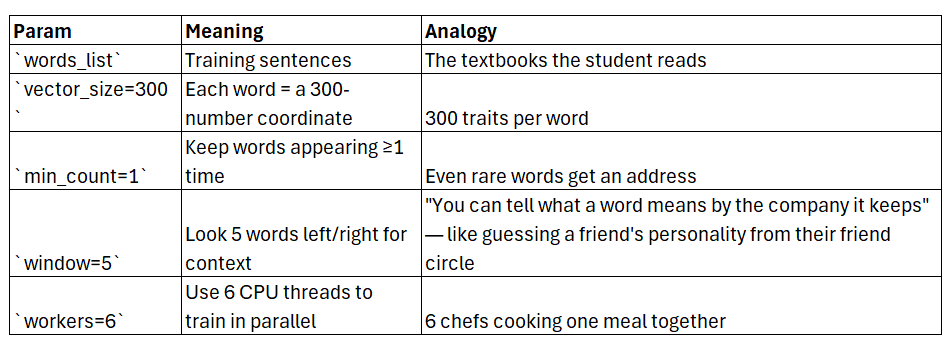
    
</div>


In [56]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 12515


In [58]:
#vocab list
list(model_W2V.wv.key_to_index)

['br',
 'movi',
 'film',
 'one',
 'like',
 'time',
 'make',
 'charact',
 'get',
 'good',
 'watch',
 'see',
 'even',
 'stori',
 'realli',
 'would',
 'end',
 'well',
 'scene',
 'peopl',
 'much',
 'look',
 'great',
 'show',
 'first',
 'think',
 'also',
 'love',
 'way',
 'play',
 'go',
 'thing',
 'act',
 'bad',
 'made',
 'could',
 'say',
 'plot',
 'know',
 'year',
 'mani',
 'tri',
 'want',
 'take',
 'seem',
 'work',
 'actor',
 'seen',
 'two',
 'never',
 'use',
 'best',
 'give',
 'come',
 'man',
 'littl',
 'life',
 'ever',
 'better',
 'perform',
 'music',
 'part',
 'back',
 'actual',
 'real',
 'live',
 'someth',
 'still',
 'lot',
 'funni',
 'anoth',
 'find',
 'noth',
 'girl',
 'feel',
 'interest',
 'director',
 'though',
 'cast',
 'point',
 'everi',
 'old',
 'origin',
 'world',
 'guy',
 '10',
 'star',
 'direct',
 'day',
 'believ',
 'new',
 'start',
 'turn',
 'kid',
 'enjoy',
 'person',
 'comedi',
 'right',
 'role',
 'fact',
 'us',
 'effect',
 'action',
 'got',
 'wonder',
 'differ',
 'becom'

Let's check out a few word embeddings obtained using the model.

In [59]:
# Checking the word embedding of a random word
word = "good"
model_W2V.wv[word]

array([ 1.00654393e-01,  5.98612666e-01, -2.33623628e-02,  3.50617081e-01,
        2.12736487e-01, -8.61815393e-01,  3.70629132e-01,  1.04291713e+00,
        2.82353997e-01, -3.03755671e-01,  1.75145254e-01, -2.60996968e-01,
        1.76383387e-02, -9.13860351e-02, -3.73493701e-01, -3.04738671e-01,
        2.67105699e-01, -7.97947347e-02,  2.00157672e-01, -1.64002866e-01,
       -2.31523976e-01, -2.01331992e-02,  4.72792357e-01,  6.44648448e-02,
        5.33989787e-01,  1.26787603e-01, -4.58004683e-01, -1.09507620e-01,
       -3.91743302e-01, -6.84768260e-01,  4.86569069e-02, -3.52537721e-01,
        5.97843602e-02, -1.69384219e-02, -1.06034614e-01,  2.15700582e-01,
        1.72768943e-02, -7.78026402e-01,  6.06694892e-02, -2.56013840e-01,
       -2.83042878e-01,  1.06077075e-01, -4.93034767e-03, -5.90174198e-01,
        2.02947080e-01,  4.85398978e-01,  1.20137790e-02,  3.99166048e-01,
       -1.05036415e-01,  5.55841744e-01,  1.42990604e-01,  8.70755017e-02,
       -3.54477763e-01,  

In [60]:
# Checking top 5 similar words to the word 'good'
similar = model_W2V.wv.similar_by_word('good', topn=5)
print(similar)

[('realli', 0.999932050704956), ('bad', 0.9999309778213501), ('think', 0.9999163746833801), ('film', 0.9999116063117981), ('made', 0.9998906254768372)]


**Note**: The similarity between words is computed using cosine similarity.

In [61]:
# Checking the word embedding of a random word
word = "best"
model_W2V.wv[word]

array([ 0.10234535,  0.58537984, -0.01940647,  0.3338092 ,  0.21681648,
       -0.83728933,  0.3519029 ,  1.0154223 ,  0.27468193, -0.28545815,
        0.15453078, -0.2439468 ,  0.01813948, -0.09638963, -0.3605298 ,
       -0.28958154,  0.2493131 , -0.07416122,  0.2077988 , -0.15872295,
       -0.22571687, -0.0287321 ,  0.45476586,  0.05384733,  0.51509786,
        0.12559807, -0.4331496 , -0.11588015, -0.37282535, -0.65590787,
        0.04994008, -0.34252214,  0.0483955 ,  0.0028904 , -0.0977123 ,
        0.20889063,  0.01081435, -0.7520172 ,  0.06391598, -0.247876  ,
       -0.271197  ,  0.10199492,  0.02033972, -0.5610096 ,  0.20766573,
        0.47379643,  0.01873008,  0.3870256 , -0.115752  ,  0.52928966,
        0.13990638,  0.08030549, -0.35091326,  0.21928461, -0.21003798,
        0.5072998 ,  0.27675316,  0.17580242,  0.10811672,  0.16449094,
       -0.0881792 , -0.245312  , -0.06429672,  0.01765152, -0.14369074,
        0.08074641, -0.12217505,  0.14933859, -0.19803452, -0.10

In [62]:
# Checking top 5 similar words to the word 'best'
similar = model_W2V.wv.similar_by_word('best', topn=5)
print(similar)

[('one', 0.999916136264801), ('action', 0.9999018311500549), ('lot', 0.9999004602432251), ('also', 0.9998977184295654), ('part', 0.9998967051506042)]


In [63]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [66]:
# word_vector_dict['bad']

In [67]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [68]:
# creating a dataframe of the vectorized documents
df_Word2Vec = pd.DataFrame(data['final_cleaned_text'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.047881,0.274530,-0.009695,0.158079,0.101296,-0.397495,0.165417,0.482039,0.131437,-0.136125,...,0.045535,0.383332,0.267324,0.090531,0.310207,0.287110,-0.002722,-0.111443,0.281052,-0.023700
1,0.052682,0.316564,-0.009139,0.188785,0.110890,-0.464302,0.196820,0.563497,0.148781,-0.163278,...,0.049332,0.451812,0.316974,0.105441,0.364279,0.339667,0.001196,-0.130645,0.330129,-0.035828
2,0.056863,0.344230,-0.009246,0.205791,0.119660,-0.504307,0.214687,0.612105,0.161669,-0.177985,...,0.053282,0.491728,0.345038,0.114744,0.396684,0.369918,0.001949,-0.142239,0.357965,-0.040686
3,0.057603,0.346310,-0.009610,0.207887,0.120819,-0.509331,0.216419,0.617991,0.162756,-0.179351,...,0.053673,0.495495,0.348286,0.115183,0.400453,0.372743,0.001936,-0.143869,0.361680,-0.040479
4,0.068413,0.391283,-0.014276,0.225477,0.144191,-0.566323,0.236770,0.688183,0.187580,-0.194878,...,0.064611,0.547256,0.382344,0.128744,0.442867,0.410537,-0.003530,-0.158398,0.400412,-0.034044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0.049308,0.283991,-0.010281,0.163950,0.105392,-0.411498,0.171908,0.499547,0.136236,-0.141940,...,0.047061,0.396971,0.277841,0.093285,0.320942,0.297441,-0.003673,-0.115364,0.290647,-0.024436
997,0.052432,0.318475,-0.008278,0.190527,0.111104,-0.467689,0.198651,0.567054,0.149042,-0.164995,...,0.049128,0.456444,0.319798,0.106118,0.367107,0.342717,0.002070,-0.131641,0.332440,-0.037477
998,0.057675,0.346633,-0.010386,0.204914,0.122045,-0.506054,0.215843,0.615158,0.163502,-0.178359,...,0.054853,0.492757,0.345138,0.114996,0.397867,0.370121,0.001237,-0.142414,0.359131,-0.038899
999,0.060160,0.342096,-0.011845,0.197358,0.125808,-0.495993,0.206489,0.601634,0.163350,-0.170439,...,0.056088,0.479400,0.334398,0.112730,0.387638,0.359726,-0.002362,-0.138037,0.350739,-0.030503


## **GloVe**

In [69]:
import numpy as np
import re

In [71]:

# Load GloVe embeddings

def load_glove(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove = load_glove("glove.6B.100d.txt")
print("Loaded words:", len(glove))

Loaded words: 400000


In [72]:

#Converting the cleaned data to list
review_texts = data['final_cleaned_text'].tolist()
print("Total reviews:", len(review_texts))

Total reviews: 1001


In [73]:

# Convert sentence → vector
def sentence_to_vec(sentence, glove, dim=100):
    words = re.findall(r'\w+', sentence)
    vectors = [glove[w] for w in words if w in glove]

    if len(vectors) == 0:
        return np.zeros(dim)

    return np.mean(vectors, axis=0)

In [74]:

#Convert all reviews → vectors

review_vectors = np.array([
    sentence_to_vec(text, glove) for text in review_texts
])

print("Vector shape:", review_vectors.shape)

Vector shape: (1001, 100)


In [93]:
review_vectors[0]

array([-0.02750502,  0.12650265,  0.27922857, -0.06529997, -0.07181375,
        0.06307659, -0.2293663 ,  0.02747156, -0.03719613, -0.03071874,
       -0.04297291,  0.00489026,  0.19247362,  0.09048302,  0.02078427,
       -0.3037487 ,  0.06304222,  0.17628504, -0.20931302,  0.4544969 ,
        0.18379977, -0.11352925,  0.04907103, -0.00477045,  0.14768745,
        0.24532667, -0.03108228, -0.18428999,  0.24877015, -0.05813772,
       -0.05866393,  0.3585384 ,  0.10304339, -0.02594594, -0.00368688,
        0.10423411,  0.12114123,  0.15054063,  0.00541499, -0.22502543,
       -0.17904711,  0.15765984,  0.12706318, -0.23930107,  0.01041691,
       -0.14782839, -0.03344344, -0.01686957,  0.19816901, -0.44387728,
       -0.11849301,  0.00848329,  0.36189246,  0.69442767,  0.07500245,
       -1.4626417 , -0.13982311,  0.05315501,  0.772641  ,  0.14177905,
        0.04989579,  0.5518957 , -0.2051974 ,  0.0572488 ,  0.47462404,
        0.15444481,  0.44994134,  0.08891595,  0.03503027, -0.00

In [75]:
def find_similar_words(word, glove, top_k=5):
    if word not in glove:
        return f"'{word}' not in vocabulary"

    word_vec = glove[word]
    similarities = []

    for w, vec in glove.items():
        sim = np.dot(word_vec, vec) / (np.linalg.norm(word_vec) * np.linalg.norm(vec) + 1e-8)
        similarities.append((w, sim))

    # sort descending
    similarities = sorted(similarities, key=lambda x: x[1], reverse=True)

    return similarities[1:top_k+1]  # skip itself

In [76]:
results = find_similar_words("good", glove, top_k=100)

for word, score in results:
    print(word, round(score, 4))

better 0.8932
sure 0.8315
really 0.8298
kind 0.8288
very 0.8261
we 0.8234
way 0.8215
think 0.8205
thing 0.8171
're 0.8142
so 0.8104
you 0.8098
lot 0.8096
n't 0.8091
things 0.8086
well 0.808
enough 0.8055
best 0.8052
always 0.8048
i 0.7993
little 0.7982
make 0.7957
excellent 0.7936
get 0.7911
've 0.7891
even 0.7884
know 0.7856
happy 0.7822
'm 0.7814
pretty 0.7799
just 0.7796
going 0.7795
but 0.7791
what 0.7764
'll 0.7756
nothing 0.7753
something 0.7742
look 0.7741
our 0.7735
too 0.7721
bad 0.7703
certainly 0.7701
much 0.7697
... 0.7682
done 0.7676
me 0.7663
maybe 0.7646
easy 0.7634
hard 0.7632
perfect 0.7631
sort 0.7618
everyone 0.7618
making 0.7617
need 0.7606
my 0.7605
do 0.76
want 0.7593
great 0.7593
because 0.756
`` 0.7547
everything 0.7542
thought 0.7529
like 0.7527
? 0.7514
if 0.7509
makes 0.7507
come 0.7497
feel 0.7494
no 0.7466
doing 0.7466
not 0.7462
getting 0.7454
yet 0.7453
'' 0.7452
how 0.7444
fact 0.7443
looking 0.7441
see 0.7427
does 0.7423
chance 0.742
anything 0.7415
giv

In [77]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

In [78]:

# Build search function
def search_database(query, top_k=2):
    query_vec = sentence_to_vec(query, glove)

    similarities = []

    for i, review_vec in enumerate(review_vectors):
        sim = cosine_similarity(query_vec, review_vec)
        similarities.append((i, sim))

    # sort by similarity
    similarities = sorted(similarities, key=lambda x: x[1], reverse=True)

    top_results = similarities[:top_k]

    return [(review_texts[i], score) for i, score in top_results]

In [79]:
results = search_database("action movie with lots of car chases", top_k=2)

for review, score in results:
    print("Score:", round(score, 4))
    print("Review:", review)
    print("-"*60)

Score: 0.9165
Review: nick cage randal rain retir car thief forc retir forc save life brother kip giovanni ribisi screw job complet brother job steal 50 car one night get togeth old crew trust help pull get bro dutch cop onto pull one great candid film make origin far classic go expect much turn think portion brain ignor plot hole an take movi end enjoy ride watch doubl bill fast furiou night high speed hijink take car spin right afterward br br grade b br br dvd extra 7 minut jerri bruckheim interview bruckheim bio filmographi action overload highlight reel big chase 0 60 featurett wild ride featurett star move cult paint heart music video theatric trailer trailer shanghai noon mission mar coyot ugli
------------------------------------------------------------
Score: 0.9145
Review: face great film great cast plot mani possibl one hollywood finest behind camera first time br br howev clear anoth 8 year spacey decid tri direct movi movi fail mani level film much action scene shot coupl 

In [94]:
# stop here

# **Machine Learning**

In [80]:
# creating a function to plot the confusion matrix
def plot_confusion_matrix(actual, predicted):
    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (5, 4))
    label_list = ['negative', 'positive']
    sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = label_list, yticklabels = label_list)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

**We'll be building Random Forest models with the vectorized data obtain from different vectorization techniques.**

## **Random Forest with Word2Vec**

In [81]:
# Storing independent variable
X = df_Word2Vec.copy()

# Storing target variable
y = data.sentiment

In [82]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.25, random_state = 42)

In [83]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 7, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [84]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test)

**Confusion Matrix**

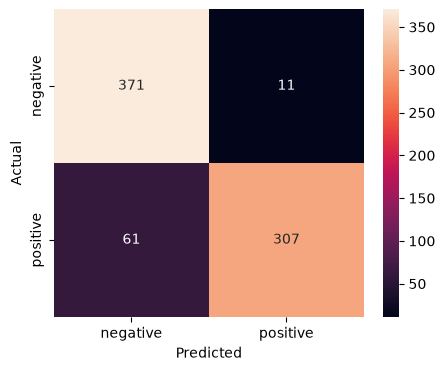

In [85]:
plot_confusion_matrix(y_train, y_pred_train)

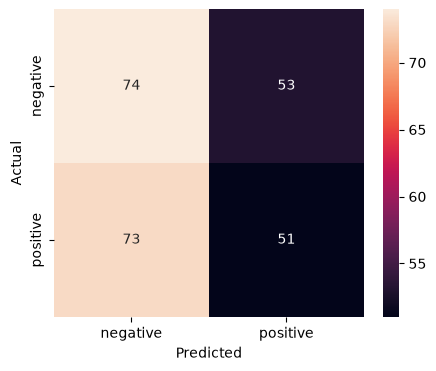

In [86]:
plot_confusion_matrix(y_test, y_pred_test)

**Classification report**

In [87]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       382
           1       0.97      0.83      0.90       368

    accuracy                           0.90       750
   macro avg       0.91      0.90      0.90       750
weighted avg       0.91      0.90      0.90       750



In [88]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.50      0.58      0.54       127
           1       0.49      0.41      0.45       124

    accuracy                           0.50       251
   macro avg       0.50      0.50      0.49       251
weighted avg       0.50      0.50      0.49       251



**Accuracy**

In [89]:
train_accuracy_Word2Vec = accuracy_score(y_train,y_pred_train)
train_accuracy_Word2Vec

0.904

In [90]:
test_accuracy_Word2Vec = accuracy_score(y_test,y_pred_test)
test_accuracy_Word2Vec

0.49800796812749004

## **Random Forest with Glove**

In [99]:
def create_glove_df(words_list, glove):
    
    glove_vectors = []
    
    for words in words_list:
        
        word_vectors = []
        
        for word in words:
            if word in glove:
                word_vectors.append(glove[word])
        
        # If no word from the review exists in GloVe
        if len(word_vectors) == 0:
            word_vectors.append(np.zeros(len(next(iter(glove.values())))))
        
        # Average all word vectors
        review_vector = np.mean(word_vectors, axis=0)
        
        glove_vectors.append(review_vector)
    
    # Create column names
    num_features = len(glove_vectors[0])
    columns = [f"feature{i}" for i in range(1, num_features + 1)]
    
    return pd.DataFrame(glove_vectors, columns=columns)

In [100]:
df_Glove = create_glove_df(words_list, glove)

In [101]:
df_Glove.head()

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,...,feature91,feature92,feature93,feature94,feature95,feature96,feature97,feature98,feature99,feature100
0,-0.027505,0.126503,0.279229,-0.065300,-0.071814,0.063077,-0.229366,0.027472,-0.037196,-0.030719,...,0.128203,-0.089681,0.026373,-0.002937,-0.177903,-0.036483,-0.090981,-0.270108,0.159297,0.184877
1,-0.035196,0.164134,0.180391,-0.268795,-0.113964,0.104027,-0.054250,0.045339,-0.001695,-0.064985,...,-0.069084,-0.033140,-0.042113,-0.070528,-0.155435,-0.108778,-0.073064,-0.133122,0.188622,0.071501
2,0.028409,0.117875,0.120898,-0.220583,-0.119684,0.101939,-0.081656,-0.028208,-0.086608,-0.058931,...,0.033776,-0.041075,-0.019412,0.155684,-0.250418,-0.199284,-0.173077,-0.398922,0.326078,0.016520
3,-0.087205,0.030615,0.216741,-0.399621,-0.223184,0.189294,-0.067806,0.156566,-0.097869,-0.251769,...,0.024919,-0.125792,0.002169,-0.036283,-0.404723,-0.146748,-0.192525,-0.187693,0.273815,0.080524
4,-0.025853,0.207978,0.258600,-0.218491,-0.172704,0.174407,-0.090386,0.028784,-0.051433,-0.107526,...,0.060010,-0.107601,0.034341,0.014119,-0.285881,0.025744,-0.184973,-0.192785,0.225520,0.172572


In [102]:
df_Glove.shape

(1001, 100)

In [103]:
# Storing independent variable
X = df_Glove.copy()

# Storing target variable
y = data.sentiment

In [104]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.25, random_state = 42)

In [105]:
# Building the model
rf_glove = RandomForestClassifier(n_estimators = 100, max_depth = 7, random_state = 42)

# Fitting on train data
rf_glove.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [106]:
# Predicting on train data
y_pred_train = rf_glove.predict(X_train)

# Predicting on test data
y_pred_test = rf_glove.predict(X_test)

**Confusion Matrix**

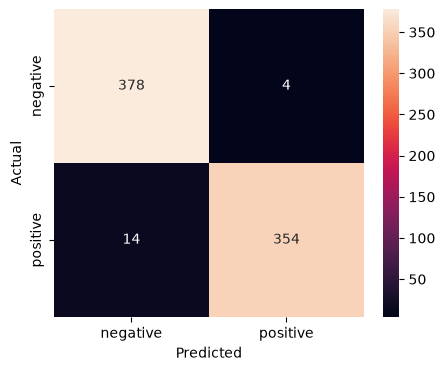

In [107]:
plot_confusion_matrix(y_train, y_pred_train)

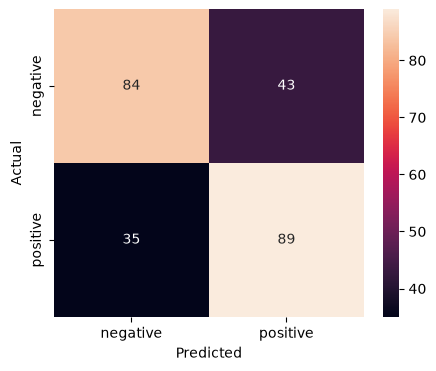

In [108]:
plot_confusion_matrix(y_test, y_pred_test)

**Classification report**

In [109]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       382
           1       0.99      0.96      0.98       368

    accuracy                           0.98       750
   macro avg       0.98      0.98      0.98       750
weighted avg       0.98      0.98      0.98       750



In [110]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.71      0.66      0.68       127
           1       0.67      0.72      0.70       124

    accuracy                           0.69       251
   macro avg       0.69      0.69      0.69       251
weighted avg       0.69      0.69      0.69       251



**Accuracy**

In [111]:
train_accuracy_GloVe = accuracy_score(y_train,y_pred_train)
train_accuracy_GloVe

0.976

In [112]:
test_accuracy_GloVe = accuracy_score(y_test,y_pred_test)
test_accuracy_GloVe

0.6892430278884463

## **Model Comparison**

In [113]:
# Create a DataFrame
model_comp = {
    'Model': ['Word2Vec', 'GloVe'],
    'Train Accuracy': [train_accuracy_Word2Vec, train_accuracy_GloVe],
    'Test Accuracy': [test_accuracy_Word2Vec, test_accuracy_GloVe]
}

# Creating the DataFrame
model_comp_df = pd.DataFrame(model_comp)

model_comp_df

,Model,Train Accuracy,Test Accuracy
0,Word2Vec,0.904,0.498008
1,GloVe,0.976,0.689243


# **Semantic Search**

We want to search our database.  We will compare a query's average word embedding to the average embedding of all the entries in the database.  The entry in the database with the most similar average embedding will be returned.

In [120]:
def embed_query(text):
  # we need to format the query the same way we formatted all the entries in the database!
  # We'll just use GloVe here, since it's the most recent model
  text = remove_special_characters(text)
  text = text.lower()
  text = text.strip()
  text = remove_stopwords(text)
  text = apply_porter_stemmer(text)
  avg_embed_query = create_glove_df(text,glove)
  return avg_embed_query

In [121]:
embed_query('Movie with lots of action and a good love story.')

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,...,feature91,feature92,feature93,feature94,feature95,feature96,feature97,feature98,feature99,feature100
0,0.294920,0.568740,-0.202450,0.502440,-0.682980,-0.251910,0.412170,0.517730,-0.88024,0.635670,...,-0.107490,0.873340,0.056184,0.783430,0.098624,-0.261120,-1.231500,-0.16875,0.518950,-0.500860
1,-0.260660,-0.022260,0.022228,-0.814330,-0.701400,0.030400,0.228440,0.532090,0.40660,0.198300,...,-0.426480,0.510920,0.521220,0.767670,-0.243950,-0.536330,-0.540560,-1.27560,-0.141220,-0.022719
2,-0.691820,0.472680,0.412920,0.204760,-0.647480,0.327710,0.524940,0.752000,-1.12040,-0.536800,...,-0.487150,0.104660,0.635300,0.760860,-0.288570,-0.070132,-0.224210,-0.29114,0.081476,-1.422200
3,-0.046539,0.619660,0.566470,-0.465840,-1.189000,0.445990,0.066035,0.319100,0.14679,-0.221190,...,-0.323430,-0.431210,0.413920,0.283740,-0.709310,0.150030,-0.215400,-0.37616,-0.032502,0.806200
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
5,-0.454330,1.023400,0.024278,-0.086367,-0.691200,-0.164200,0.457260,0.303010,-0.43587,-0.038917,...,-0.379990,0.123600,0.344500,-0.104450,0.770920,-0.075528,-0.176880,-0.43769,1.016900,-0.267060
6,-0.260660,-0.022260,0.022228,-0.814330,-0.701400,0.030400,0.228440,0.532090,0.40660,0.198300,...,-0.426480,0.510920,0.521220,0.767670,-0.243950,-0.536330,-0.540560,-1.27560,-0.141220,-0.022719
7,0.134820,0.402240,-0.422660,-0.055631,-0.557420,0.043634,0.049172,0.173820,-0.74579,-0.113060,...,0.016522,0.104960,0.269310,-0.364830,-0.062628,-0.361800,-0.147530,-0.27989,0.289370,0.043783
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
9,-0.270860,0.044006,-0.020260,-0.173950,0.644400,0.712130,0.355100,0.471380,-0.29637,0.544270,...,0.572010,0.088945,-0.425320,-0.018253,-0.079995,-0.285810,-0.010890,-0.49230,0.636870,0.236420


In [122]:
glove_numpy = df_Glove.to_numpy()
def search_database(query,top_k=5):
  query_embed = embed_query(query)
  query_norm = np.sqrt(np.sum(query_embed**2))
  cosine_sim = np.dot(glove_numpy,query_embed)/query_norm
  for i in range(df_Glove.shape[0]):
    cosine_sim[i] /= np.sqrt(np.sum(glove_numpy[i,:]**2))
  best_index = np.argsort(cosine_sim)[::-1]
  best_index = best_index[:top_k]
  return best_index

In [123]:
best_ind = search_database('Action movie with lots of car chases.',top_k=2)
best_ind

ValueError: shapes (1001,100) and (25,100) not aligned: 100 (dim 1) != 25 (dim 0)

In [ ]:
data['review'][best_ind]

# **Conclusion**

- We used different text processing techniques to clean the raw text data.

- We then vectorized the cleaned text data using the following methods:

    - Word2Vec
    - GloVe

- We then built ML models using the different vectorized datasets.
- We also used these vectorized datasets for semantic search.

##### <u> Imp note - This notebook uses gensim library for word2vec, which does not work on Python 3.14. It will work on python 3.12. You will have to get python 3.12 version on your system and select that in the kernel while running this notebook. Additionally you will have to intall all dependencies/ libraries separately once again for using python 3.12 viz pandas, sklearn, matplotlib etc. </u>

#### Steps to check current versions.
1. Check current versions of Python on cmd line-
   py -0
2. If 3.12 does not exixt, download and install from python.org
3. Register Python 3.12 so it appears inside Jupyter Notebook: use cmd line
   py -3.12 -m ipykernel install --user --name python312 --display-name "Python 3.12"
4. Install gensis:
   py -3.12 -m pip install ipykernel gensim

<font size=5 color='blue'>Power Ahead!</font>
___